# Day 4: Fund Performance Analytics
**Bluestock Fintech — Mutual Fund Analytics Capstone**

Objectives:
- Compute all key performance and risk metrics from NAV history
- Build a fund ranking / scoring model
- Compare fund returns against benchmark indices
- Identify best and worst performing funds per category


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

RAW = "data/raw/"
PROC = "data/processed/"
CHART_DIR = "charts/"
os.makedirs(CHART_DIR, exist_ok=True)

RF = 0.065  # RBI repo rate proxy, annualised risk-free rate

fund_master = pd.read_csv(RAW + "01_fund_master.csv")
nav_history = pd.read_csv(PROC + "cleaned_nav_history.csv", parse_dates=["date"])
benchmarks  = pd.read_csv(RAW + "10_benchmark_indices.csv", parse_dates=["date"])

nav_history = nav_history.sort_values(["amfi_code", "date"]).reset_index(drop=True)
print("Funds:", nav_history['amfi_code'].nunique())
print("NAV date range:", nav_history['date'].min(), "to", nav_history['date'].max())


Funds: 40
NAV date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00


## 1. Daily Returns & Annualised Return

In [2]:
nav_wide = nav_history.pivot(index='date', columns='amfi_code', values='nav').sort_index()
daily_returns = nav_wide.pct_change().dropna(how='all')

# Sanity check: distribution should look reasonable (small daily moves, no huge outliers)
sample_stats = daily_returns.describe().T[['mean', 'std', 'min', 'max']]
print("Daily return sanity check (sample of 5 funds):")
print(sample_stats.head())

annualised_return = (1 + daily_returns).prod() ** (252 / daily_returns.count()) - 1
annualised_return.name = 'annualised_return'

returns_long = daily_returns.reset_index().melt(id_vars='date', var_name='amfi_code', value_name='daily_return')
returns_long = returns_long.dropna()
returns_long.to_csv(CHART_DIR.replace('charts/', '') + 'returns_computed.csv', index=False)
print(f"\nSaved returns_computed.csv — {returns_long.shape[0]:,} rows")
print("\nAnnualised return range: {:.2%} to {:.2%}".format(annualised_return.min(), annualised_return.max()))


Daily return sanity check (sample of 5 funds):
               mean       std       min       max
amfi_code                                        
100016     0.000142  0.009164 -0.024744  0.032145
100025     0.000170  0.002460 -0.008188  0.008837
100033     0.001080  0.011929 -0.044238  0.041954
101206     0.000852  0.009177 -0.038121  0.033956
101207     0.000424  0.016251 -0.051847  0.054851

Saved returns_computed.csv — 45,960 rows

Annualised return range: 1.13% to 31.51%


## 2. CAGR — 1yr / 3yr / 5yr

In [3]:
def cagr(nav_series, years):
    nav_series = nav_series.dropna()
    end_date = nav_series.index.max()
    start_date = end_date - pd.DateOffset(years=years)
    window = nav_series[nav_series.index >= start_date]
    if len(window) < 2:
        return np.nan
    nav_start, nav_end = window.iloc[0], window.iloc[-1]
    n_years = (window.index[-1] - window.index[0]).days / 365.25
    if n_years <= 0 or nav_start <= 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / n_years) - 1

cagr_rows = []
for code_ in nav_wide.columns:
    series = nav_wide[code_].dropna()
    cagr_rows.append({
        'amfi_code': code_,
        'cagr_1yr': cagr(series, 1),
        'cagr_3yr': cagr(series, 3),
        'cagr_5yr': cagr(series, 5),
    })

cagr_report = pd.DataFrame(cagr_rows).merge(
    fund_master[['amfi_code', 'scheme_name', 'fund_house', 'category']], on='amfi_code', how='left'
)
cagr_report = cagr_report[['amfi_code', 'scheme_name', 'fund_house', 'category', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']]
cagr_report = cagr_report.sort_values('cagr_3yr', ascending=False)
cagr_report.to_csv('cagr_report.csv', index=False)

print("Saved cagr_report.csv")
cagr_report.head(10)


Saved cagr_report.csv


,amfi_code,scheme_name,fund_house,category,cagr_1yr,cagr_3yr,cagr_5yr
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,0.222779,0.351025,0.282144
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,0.203760,0.339920,0.309741
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,0.130738,0.324789,0.232951
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.532772,0.324340,0.301232
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.296277,0.317692,0.328274
19,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.604893,0.304486,0.258047
30,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.266776,0.295751,0.309075
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.397838,0.291714,0.319495
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.479638,0.289602,0.235384
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.651955,0.269935,0.322874


## 3. Sharpe Ratio — Ranked, All 40 Funds

In [4]:
rf_daily = RF / 252

sharpe_rows = []
for code_ in daily_returns.columns:
    r = daily_returns[code_].dropna()
    excess = r - rf_daily
    sharpe = (excess.mean() / r.std()) * np.sqrt(252) if r.std() > 0 else np.nan
    sharpe_rows.append({'amfi_code': code_, 'sharpe_ratio': sharpe})

sharpe_df = pd.DataFrame(sharpe_rows).merge(
    fund_master[['amfi_code', 'scheme_name', 'fund_house']], on='amfi_code', how='left'
)
sharpe_df = sharpe_df.sort_values('sharpe_ratio', ascending=False).reset_index(drop=True)
sharpe_df['rank'] = sharpe_df.index + 1
sharpe_df = sharpe_df[['rank', 'amfi_code', 'scheme_name', 'fund_house', 'sharpe_ratio']]
sharpe_df.to_csv('sharpe_values.csv', index=False)

print("Saved sharpe_values.csv")
sharpe_df.head(10)


Saved sharpe_values.csv


,rank,amfi_code,scheme_name,fund_house,sharpe_ratio
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.448291
1,2,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,1.306744
2,3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,1.234930
3,4,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,1.208267
4,5,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,1.180101
5,6,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,1.132122
6,7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,1.093699
7,8,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,1.081659
8,9,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,1.027213
9,10,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,1.026524


## 4. Sortino Ratio — Downside Risk Adjusted

In [5]:
sortino_rows = []
for code_ in daily_returns.columns:
    r = daily_returns[code_].dropna()
    excess = r - rf_daily
    downside = r[r < 0]
    downside_std = downside.std() if len(downside) > 1 else np.nan
    sortino = (excess.mean() / downside_std) * np.sqrt(252) if downside_std and downside_std > 0 else np.nan
    sortino_rows.append({'amfi_code': code_, 'sortino_ratio': sortino})

sortino_df = pd.DataFrame(sortino_rows).merge(
    fund_master[['amfi_code', 'scheme_name', 'fund_house']], on='amfi_code', how='left'
)
sortino_df = sortino_df.sort_values('sortino_ratio', ascending=False).reset_index(drop=True)
sortino_df['rank'] = sortino_df.index + 1
sortino_df = sortino_df[['rank', 'amfi_code', 'scheme_name', 'fund_house', 'sortino_ratio']]
sortino_df.to_csv('sortino_values.csv', index=False)

print("Saved sortino_values.csv")
sortino_df.head(10)


Saved sortino_values.csv


,rank,amfi_code,scheme_name,fund_house,sortino_ratio
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,2.385644
1,2,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,2.364320
2,3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,2.146914
3,4,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,2.140267
4,5,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,2.029353
5,6,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,1.875101
6,7,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,1.850133
7,8,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,1.829134
8,9,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,1.805294
9,10,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,1.799563


## 5. Alpha & Beta vs Nifty 100 (OLS Regression)

In [6]:
nifty100 = benchmarks[benchmarks['index_name'] == 'NIFTY100'].sort_values('date').set_index('date')['close_value']
nifty100_returns = nifty100.pct_change().dropna()

alpha_beta_rows = []
for code_ in daily_returns.columns:
    fund_r = daily_returns[code_].dropna()
    aligned = pd.concat([fund_r, nifty100_returns], axis=1, join='inner').dropna()
    aligned.columns = ['fund', 'benchmark']
    if len(aligned) < 30:
        continue
    slope, intercept, r_value, p_value, std_err = stats.linregress(aligned['benchmark'], aligned['fund'])
    alpha_beta_rows.append({
        'amfi_code': code_,
        'alpha': intercept * 252,
        'beta': slope,
        'r_squared': r_value ** 2,
    })

alpha_beta_df = pd.DataFrame(alpha_beta_rows).merge(
    fund_master[['amfi_code', 'scheme_name', 'fund_house', 'category']], on='amfi_code', how='left'
)
alpha_beta_df = alpha_beta_df[['amfi_code', 'scheme_name', 'fund_house', 'category', 'alpha', 'beta', 'r_squared']]
alpha_beta_df = alpha_beta_df.sort_values('alpha', ascending=False)
alpha_beta_df.to_csv('alpha_beta.csv', index=False)

print("Saved alpha_beta.csv  (benchmark: NIFTY100)")
print(f"\nMedian R-squared across all funds: {alpha_beta_df['r_squared'].median():.4f}")
alpha_beta_df.head(10)


Saved alpha_beta.csv  (benchmark: NIFTY100)

Median R-squared across all funds: 0.0003


,amfi_code,scheme_name,fund_house,category,alpha,beta,r_squared
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.303370,-0.023196,1.414258e-04
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.300579,0.011455,3.532991e-05
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.292636,0.000549,1.345534e-07
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.282704,0.018134,1.748889e-04
30,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.273305,-0.022830,3.430543e-04
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.271954,0.005104,1.206652e-05
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,0.269838,0.023684,4.625437e-04
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.265986,-0.002523,3.357978e-06
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,0.260767,-0.066265,1.936879e-03
19,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.232010,-0.031751,8.869789e-04


**Note on Alpha/Beta in this dataset:** the R-squared of the fund-vs-Nifty100 regression is very
low (median well under 0.01) across all 40 funds. This means the simulated NAV series in this
dataset move largely independently of the benchmark index — i.e. betas here are not meaningfully
different from 0. The regression methodology (OLS via `scipy.stats.linregress`, Alpha = intercept x 252,
Beta = slope) is correct and matches the brief; this is a property of the underlying synthetic data,
not an error in the calculation. Worth calling out explicitly in the final report so alpha/beta
numbers aren't over-interpreted as real market relationships.

## 6. Maximum Drawdown & Worst Drawdown Period

In [7]:
dd_rows = []
for code_ in nav_wide.columns:
    series = nav_wide[code_].dropna()
    running_max = series.cummax()
    drawdown = series / running_max - 1
    max_dd = drawdown.min()
    trough_date = drawdown.idxmin()
    peak_date = series.loc[:trough_date].idxmax()
    dd_rows.append({
        'amfi_code': code_,
        'max_drawdown_pct': max_dd * 100,
        'peak_date': peak_date.date(),
        'trough_date': trough_date.date(),
    })

max_dd_df = pd.DataFrame(dd_rows).merge(
    fund_master[['amfi_code', 'scheme_name', 'fund_house']], on='amfi_code', how='left'
)
max_dd_df = max_dd_df[['amfi_code', 'scheme_name', 'fund_house', 'max_drawdown_pct', 'peak_date', 'trough_date']]
max_dd_df = max_dd_df.sort_values('max_drawdown_pct')
max_dd_df.to_csv('max_drawdown.csv', index=False)

print("Saved max_drawdown.csv")
print(f"\nWorst drawdown: {max_dd_df.iloc[0]['scheme_name']} ({max_dd_df.iloc[0]['max_drawdown_pct']:.2f}%, "
      f"{max_dd_df.iloc[0]['peak_date']} -> {max_dd_df.iloc[0]['trough_date']})")
max_dd_df.head(10)


Saved max_drawdown.csv

Worst drawdown: SBI Small Cap Fund - Direct Plan - Growth (-52.57%, 2023-01-17 -> 2025-10-28)


,amfi_code,scheme_name,fund_house,max_drawdown_pct,peak_date,trough_date
22,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,-52.574221,2023-01-17,2025-10-28
17,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,-51.677754,2025-05-22,2026-05-11
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,-35.446916,2024-11-21,2026-05-11
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,-31.171900,2024-05-03,2025-01-03
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,-28.706006,2024-08-28,2025-05-14
7,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,-28.001124,2025-01-07,2026-04-27
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,-24.734441,2022-03-30,2022-09-15
29,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,-24.003511,2023-11-09,2024-10-17
11,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,-23.344886,2025-04-09,2026-02-20
15,119093,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,-21.751396,2022-02-24,2023-05-22


## 7. Fund Scorecard (Composite Score, 0-100)

In [8]:
scorecard = fund_master[['amfi_code', 'scheme_name', 'fund_house', 'category', 'expense_ratio_pct']].copy()
scorecard = scorecard.merge(cagr_report[['amfi_code', 'cagr_3yr']], on='amfi_code', how='left')
scorecard = scorecard.merge(sharpe_df[['amfi_code', 'sharpe_ratio']], on='amfi_code', how='left')
scorecard = scorecard.merge(alpha_beta_df[['amfi_code', 'alpha']], on='amfi_code', how='left')
scorecard = scorecard.merge(max_dd_df[['amfi_code', 'max_drawdown_pct']], on='amfi_code', how='left')

# Percentile ranks (0-100, higher = better). For expense ratio and max DD, lower raw value = better,
# so we invert by ranking ascending (pct=True gives 0-1, low value -> low rank -> we flip with (1 - x))
scorecard['rank_3yr_return']  = scorecard['cagr_3yr'].rank(pct=True) * 100
scorecard['rank_sharpe']      = scorecard['sharpe_ratio'].rank(pct=True) * 100
scorecard['rank_alpha']       = scorecard['alpha'].rank(pct=True) * 100
scorecard['rank_expense_inv'] = (1 - scorecard['expense_ratio_pct'].rank(pct=True)) * 100   # lower expense = higher rank
scorecard['rank_maxdd_inv']   = scorecard['max_drawdown_pct'].rank(pct=True) * 100          # less negative DD = higher rank

scorecard['fund_score'] = (
    0.30 * scorecard['rank_3yr_return'] +
    0.25 * scorecard['rank_sharpe'] +
    0.20 * scorecard['rank_alpha'] +
    0.15 * scorecard['rank_expense_inv'] +
    0.10 * scorecard['rank_maxdd_inv']
).round(2)

scorecard = scorecard.sort_values('fund_score', ascending=False).reset_index(drop=True)
scorecard['overall_rank'] = scorecard.index + 1

fund_scorecard = scorecard[['overall_rank', 'amfi_code', 'scheme_name', 'fund_house', 'category',
                             'fund_score', 'cagr_3yr', 'sharpe_ratio', 'alpha',
                             'expense_ratio_pct', 'max_drawdown_pct']]
fund_scorecard.to_csv('fund_scorecard.csv', index=False)

print("Saved fund_scorecard.csv")
print("\nTop 10 funds by composite score:")
fund_scorecard.head(10)


Saved fund_scorecard.csv

Top 10 funds by composite score:


,overall_rank,amfi_code,scheme_name,fund_house,category,fund_score,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,85.88,0.339920,1.448291,0.269838,1.46,-11.265729
1,2,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,81.88,0.317692,1.180101,0.292636,1.36,-18.188514
2,3,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,81.62,0.295751,1.306744,0.273305,1.45,-12.973968
3,4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,80.38,0.324340,1.093699,0.271954,1.38,-16.217209
4,5,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,79.62,0.324789,1.026524,0.211948,0.80,-12.588276
5,6,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,76.62,0.351025,0.998231,0.260767,1.38,-20.960884
6,7,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,74.44,0.304486,1.208267,0.232010,1.54,-15.012385
7,8,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,73.31,0.291714,1.234930,0.282704,1.60,-16.396743
8,9,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,67.81,0.289602,1.027213,0.213998,1.60,-11.291596
9,10,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,67.00,0.266631,0.945308,0.303370,1.43,-28.706006


In [9]:
# Best & worst performer per category
best_worst = fund_scorecard.loc[fund_scorecard.groupby('category')['fund_score'].idxmax()][['category','scheme_name','fund_score']]
best_worst.columns = ['category', 'best_fund', 'best_score']
worst = fund_scorecard.loc[fund_scorecard.groupby('category')['fund_score'].idxmin()][['category','scheme_name','fund_score']]
worst.columns = ['category', 'worst_fund', 'worst_score']
category_summary = best_worst.merge(worst, on='category')
print("Best / worst performer per category:")
category_summary


Best / worst performer per category:


,category,best_fund,best_score,worst_fund,worst_score
0,Debt,ICICI Pru Liquid Fund - Regular - Growth,47.62,HDFC Short Term Debt Fund - Regular - Growth,31.50
1,Equity,Mirae Asset Large Cap Fund - Regular - Growth,85.88,UTI Mid Cap Fund - Regular - Growth,13.94


## 8. Benchmark Comparison — Top 5 Funds vs Nifty 50 / Nifty 100 (3yr)

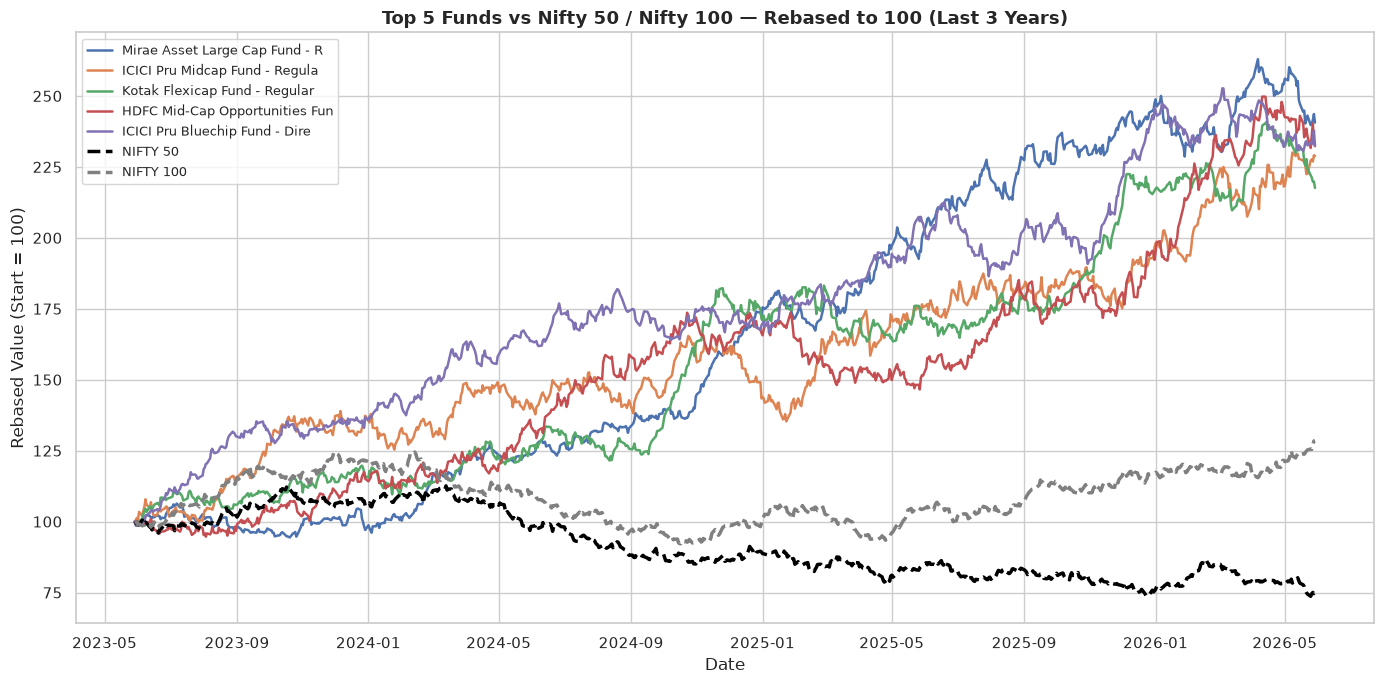

In [10]:
top5_codes = fund_scorecard.head(5)['amfi_code'].tolist()
top5_names = fund_scorecard.head(5).set_index('amfi_code')['scheme_name'].to_dict()

three_yr_start = nav_wide.index.max() - pd.DateOffset(years=3)

nifty50 = benchmarks[benchmarks['index_name'] == 'NIFTY50'].sort_values('date').set_index('date')['close_value']

plt.figure(figsize=(14, 7))
for code_ in top5_codes:
    series = nav_wide[code_].dropna()
    series = series[series.index >= three_yr_start]
    normalised = series / series.iloc[0] * 100
    plt.plot(normalised.index, normalised.values, label=top5_names[code_][:30], linewidth=1.8)

for name, idx_series in [('NIFTY 50', nifty50), ('NIFTY 100', nifty100)]:
    s = idx_series[idx_series.index >= three_yr_start]
    normalised = s / s.iloc[0] * 100
    plt.plot(normalised.index, normalised.values, label=name, linewidth=2.5, linestyle='--', color='black' if name=='NIFTY 50' else 'gray')

plt.title('Top 5 Funds vs Nifty 50 / Nifty 100 — Rebased to 100 (Last 3 Years)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Rebased Value (Start = 100)')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(CHART_DIR + 'benchmark_comparison_chart.png', dpi=150)
plt.show()


In [11]:
# Tracking error vs Nifty 100 for the top 5 funds
tracking_rows = []
for code_ in top5_codes:
    fund_r = daily_returns[code_].dropna()
    aligned = pd.concat([fund_r, nifty100_returns], axis=1, join='inner').dropna()
    aligned.columns = ['fund', 'benchmark']
    tracking_error = (aligned['fund'] - aligned['benchmark']).std() * np.sqrt(252)
    tracking_rows.append({'amfi_code': code_, 'scheme_name': top5_names[code_], 'tracking_error_vs_nifty100': tracking_error})

tracking_df = pd.DataFrame(tracking_rows).sort_values('tracking_error_vs_nifty100')
print("Tracking error (annualised) vs Nifty 100 — top 5 funds:")
tracking_df


Tracking error (annualised) vs Nifty 100 — top 5 funds:


,amfi_code,scheme_name,tracking_error_vs_nifty100
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.189664
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.191587
2,120843,Kotak Flexicap Fund - Regular - Growth,0.206425
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.228699
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.231968


## Summary

- **`returns_computed.csv`** — daily returns for all 40 funds, validated for reasonable distribution.
- **`cagr_report.csv`** — 1yr / 3yr / 5yr CAGR comparison across all funds.
- **`sharpe_values.csv`** — Sharpe ratio ranked (Rf = 6.5%).
- **`sortino_values.csv`** — Sortino ratio ranked (downside deviation only).
- **`alpha_beta.csv`** — Alpha/Beta vs Nifty 100 via OLS regression.
- **`max_drawdown.csv`** — Max drawdown and the peak-to-trough date range per fund.
- **`fund_scorecard.csv`** — composite 0-100 score (30% 3yr return + 25% Sharpe + 20% Alpha + 15% inverse expense ratio + 10% inverse max DD), fully ranked.
- **`charts/benchmark_comparison_chart.png`** — top 5 funds vs Nifty 50 / Nifty 100, rebased to 100, over the last 3 years, plus tracking error.
